<h2 style="color:green", text align='center';> ISAT 449: Emerging Topics in Applied Data Science

<br>

<img src="images/mnist.png" width=450; height=450>  
    
<h2 style="color: blue", text align='center';>Lab 3: Training a Multilayer Perceptron Model using Scikit-Learn
    
<h4 style="color: blue", text align='center';>(Image Recognition of the MNIST Handwritten Digits Dataset)

<h4 text align='center'> (Kelsey Robertson and Allie Zombron) </h4>

### MNIST classification with SciKit-Learn using MLPClassifier

This notebook shows how to define and train a simple Neural-Network with SciKit-Learn's MLPClasifier.

### Learning Objectives
- Import and learn about the MNIST dataset and its structure
- Create trianing , validation and test datasets from the MNIST data
- Build a simple but effective Scikit Learn MLPClassifier model for recognizing digits, based on looking at every pixel in the image

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt


When one learns how to program, there's a tradition that the first thing you do is print "Hello World." Just like programming has Hello World, machine learning has MNIST.

MNIST is a simple computer vision dataset. It consists of images of handwritten digits like these:
<img src="images/mnist_image.png" width=300; height=300>  
It also includes labels for each image, telling us which digit it is. For example, the labels for the above images are 5, 0, 4, and 1

### Loading Data
Using SciKit-Learns fetch_openml to load MNIST data.

In [2]:
# Load data from https://www.openml.org/d/554
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
mnist = fetch_openml(name='mnist_784',parser='pandas',version=1, cache=False)


### Print the Shape of the data

In [3]:
mnist.data.shape


(70000, 784)

There are 70,000 images and each image has 784 features (each image is 28 x 28 pixels and each pixel represents a feature of an image)

### Preprocessing Data

Each image of the MNIST dataset is encoded in a 784 dimensional vector, representing a 28 x 28 pixel image. Each pixel has a value between
0 and 255, representing the pixels intensity, from 0 (white) to 255 (black) corresponding to the grey-value of a pixel.

The above `featch_mldata` method to load MNIST returns data and target as `uint8` which we convert to `float32` and `int64` respectively.

In [4]:
X = mnist.data.astype('float32')
y = mnist.target.astype('int64')

In [5]:
X.head(1)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


To avoid big weights that deal with the pixel values from between [0, 255], we scale X down. A commonly used range is [0, 1].

In [6]:
X/=255.0

In [7]:
X.min(), X.max()

(pixel1      0.0
 pixel2      0.0
 pixel3      0.0
 pixel4      0.0
 pixel5      0.0
            ... 
 pixel780    0.0
 pixel781    0.0
 pixel782    0.0
 pixel783    0.0
 pixel784    0.0
 Length: 784, dtype: float64,
 pixel1      0.000000
 pixel2      0.000000
 pixel3      0.000000
 pixel4      0.000000
 pixel5      0.000000
               ...   
 pixel780    0.243137
 pixel781    0.000000
 pixel782    0.000000
 pixel783    0.000000
 pixel784    0.000000
 Length: 784, dtype: float64)

Note: initial data is not normalized.

#### Train/Test Split 

The MNIST data is already split into a training set (the first 60,000 images) and a test set (the last 10,000 images). Furthermore, the training set is already shuffled for us! So we can just use python list slicing to generate our datasets from the full set of images.

In [8]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

#### Print shapes of training and testing sets

In [9]:
X_train.shape, y_train.shape


((60000, 784), (60000,))

In [10]:
#X_train.to_csv("X_train.csv",header=False, index=True)

### Print a selection of training images and their labels

In [11]:
def plot_example(X, y):
    """Plot the first 5 images and their labels in a row."""
    for i, (img, y) in enumerate(zip(X[:5].values.reshape(5, 28, 28), y[:5])):
        plt.subplot(151 + i)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(y)

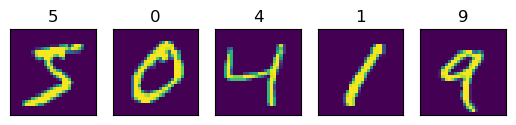

In [12]:
plot_example(X_train, y_train)

### Is the Training Dataset Balanced?

Let's plot a histogram of the training dastset labels class labels to make sure we have a balanaced dataset, i.e.we want to figure out how often each number is represented in the training dataset This is important when we are trying to eliminate **algorithmic bias** in our machine learning models.

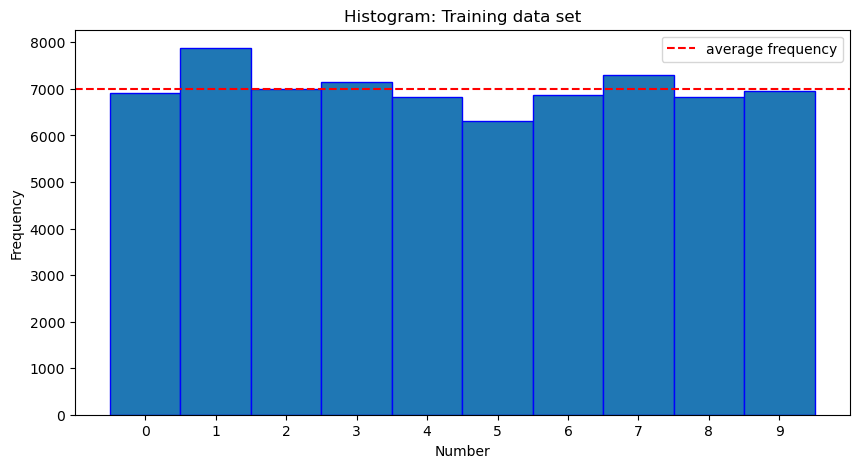

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,5))
ax.hist(y,bins=[0,1,2,3,4,5,6,7,8,9,10], edgecolor="b", histtype="bar",align='left')
ax.set_title('Histogram: Training data set')
ax.set(xlabel='Number', ylabel='Frequency')
ax.xaxis.set_ticks([0,1,2,3,4,5,6,7,8,9] );
ax.axhline(y=(y.size/10), label="average frequency",linestyle='dashed', color='r')
ax.legend()

We can see the number of examples for each number to detect is not even distributed. There are more 1, 3 and 7 in the dataset.

## Build Neural Network with Scikit Learn MultiLayer Perceptron Classifier

Let's build a simple, fully connected neural network with three hidden layers with the following parameters:

### The Model using a Multilayer Perceptron Classifier
**Build the model with 3 hidden layers as follows:** 
- hidden layer = 256 neurons
- hidden layer = 128 neurons
- hidden layer = 32 neurons

**also, use these parameters**
- solver ='adam'
- learning_rate_init= 0.001
- tol=1e-2
- max_iter= 500
- verbose = True
- random_state=1

You can use the default values for the rest of the parameters

Input layer has 784 dimensions (28x28), and the output layer 10 neurons, representing digits 0 - 9. The MLPClassifier implements a multi-layer perceptron (MLP) algorithm that trains using Backpropagation. MLP trains on two arrays: array X of size (n_samples, n_features), which holds the training samples represented as floating point feature vectors; and array y of size (n_samples,), which holds the target values (class labels) for the training samples:

In [14]:
from sklearn.neural_network import MLPClassifier
#TO-DO Instantiate the model and name it as below
mlp_mnist_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 32),  
    solver='adam',                     
    learning_rate_init=0.001,          
    tol=1e-2,                       
    max_iter=500, 
    verbose=True,
    random_state=1) 

In [15]:
mlp_mnist_model.fit(X_train, y_train)

Iteration 1, loss = 0.34110846
Iteration 2, loss = 0.12689621
Iteration 3, loss = 0.08622532
Iteration 4, loss = 0.06181403
Iteration 5, loss = 0.04469420
Iteration 6, loss = 0.03410506
Iteration 7, loss = 0.02856108
Iteration 8, loss = 0.02109429
Iteration 9, loss = 0.01839320
Iteration 10, loss = 0.01591000
Iteration 11, loss = 0.01278140
Iteration 12, loss = 0.01484089
Iteration 13, loss = 0.01096972
Iteration 14, loss = 0.01185615
Iteration 15, loss = 0.01366165
Iteration 16, loss = 0.00904405
Iteration 17, loss = 0.00949689
Training loss did not improve more than tol=0.010000 for 10 consecutive epochs. Stopping.


MLPClassifier(hidden_layer_sizes=(256, 128, 32), max_iter=500, random_state=1,
              tol=0.01, verbose=True)

In [16]:
mlp_mnist_model.out_activation_

'softmax'

In [17]:
mlp_mnist_model.n_layers_

5

In [18]:
mlp_mnist_model.n_outputs_

10

In [19]:
mlp_mnist_model.n_iter_

17

### Model Evaluation and Performance 

In [20]:
mlp_mnist_model.score(X_test, y_test)

0.9802

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
y_pred = mlp_mnist_model.predict(X_test)

In [23]:
accuracy_score(y_test, y_pred)

0.9802

An accuracy of about 98% for a network with only two hidden layers is not too bad.

Let's take a look at some predictions that **went wrong:**

In [24]:
error_mask = y_pred != y_test

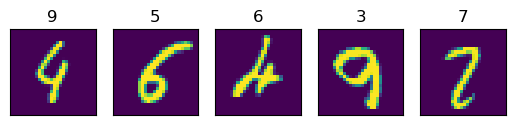

In [25]:
plot_example(X_test[error_mask], y_pred[error_mask])

In [26]:
loss_values = mlp_mnist_model.loss_curve_

In [27]:
print('loss values are {}'.format(loss_values))

loss values are [0.34110846042951276, 0.1268962077084755, 0.08622531972503983, 0.0618140271280228, 0.04469420270366452, 0.03410505501210421, 0.02856107559458942, 0.021094294046016652, 0.018393198658387414, 0.01590999714511766, 0.012781404164148743, 0.01484088965185636, 0.010969719026041283, 0.011856150617592237, 0.013661649008111485, 0.009044045799834964, 0.009496885942264298]


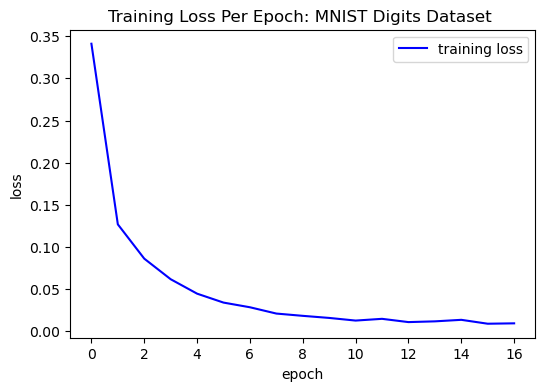

In [28]:
# TO-DO Plot the loss_values (Label each axis, put in a legend and put a title on plot.)
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6, 4))
plt.plot(loss_values, color="blue", label = 'training loss')
plt.xlabel('epoch')
plt.ylabel('loss');
#legend
plt.legend(loc='upper right')
#title
plt.title('Training Loss Per Epoch: MNIST Digits Dataset ')
#show plot
plt.show()

#### Classification Report

In [29]:
from sklearn import metrics
print ("Classification Report:")
print (metrics.classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.96      0.99      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.99      0.97      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



#### Confusion Matrix
A further statistic is the confusion matrix that shows the errors that the classifier made during training.

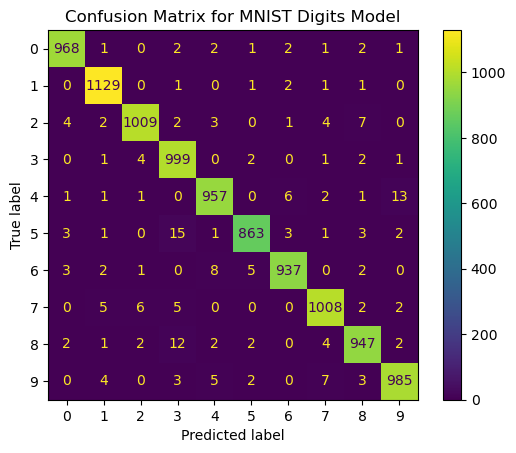

In [30]:
#TO-DO: print a pretty confusion matrix (see previous notebooks)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix for the MNIST model
cm = confusion_matrix(y_test, y_pred, labels=np.arange(10))

# Create a ConfusionMatrixDisplay object with the correct labels (0-9)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))

# Plot the confusion matrix
disp.plot() 
plt.title('Confusion Matrix for MNIST Digits Model')
plt.show()


<h2 style="color: red", text align='center';> Exercises

#### <font color="green">Answer the questions below in your notebook. Submit your completed Jupyter Notebook. Please Zip it with any other files or folders you have (your images should be in a separate images folder).

### Exercise 1 (5 points)
- Based on the confusion matrix, which digit was hardest for the model to classify? Justify your answer!.

The digit that was hardest to classify was digit 5. This was because of the model trying to classify it as several other digits. For example, the model tried to classify digit 5 as digit 3 fifteen different times. Also, the model attempted to classify digit 5 as other digits on multiple other occasions as well.

### Exercise 2 (10 points)
- Based on the output of your **classification report**, out of all the times `digit 7` should have been predicted, what percentage of times was it correctly predicted? (HINT: You may need to research the meaning and difference between precision, recall and f1-score)
- Do a simple calculation (do it here!) to justify your answer. It compares to what metric in the classification report?

**Out of all the times digit 7 should have predicted, the model correctly predicted 7 98% of the time. This compares to the recall metric in the classification report.**

- Recall for digit 7 = 98%`
- Support for digit 7 = 1028

True positive = .98 * 1028 = 1007.44

1007 instances of digit 7 were predicted correctly

Recall = 1007.644/1028 = .98

- Recall - Out of all the data points that should be predicted as true, how many did we correctly predict as true? (recall definition)


### Exercise 3 (10 points)
- Train the model using the 'sgd' optimizer (scikit learn calls it a solver). Does the accuracy improve? Comment (one line!) as to what you think is contributing to the change in performance of the model.

In [31]:
mlp_mnist_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 32),  
    solver='sgd',                     
    learning_rate_init=0.001,          
    tol=1e-2,                       
    max_iter=500, 
    verbose=True,
    random_state=1) 

mlp_mnist_model.fit(X_train, y_train)

mlp_mnist_model.score(X_test, y_test)

Iteration 1, loss = 1.70057155
Iteration 2, loss = 0.65671763
Iteration 3, loss = 0.43655073
Iteration 4, loss = 0.36794087
Iteration 5, loss = 0.33161744
Iteration 6, loss = 0.30703774
Iteration 7, loss = 0.28804398
Iteration 8, loss = 0.27250223
Iteration 9, loss = 0.25887135
Iteration 10, loss = 0.24714255
Iteration 11, loss = 0.23634392
Iteration 12, loss = 0.22664972
Iteration 13, loss = 0.21761617
Iteration 14, loss = 0.20970263
Iteration 15, loss = 0.20201468
Iteration 16, loss = 0.19497689
Iteration 17, loss = 0.18807919
Iteration 18, loss = 0.18187857
Iteration 19, loss = 0.17621118
Iteration 20, loss = 0.17050658
Iteration 21, loss = 0.16533377
Iteration 22, loss = 0.16050391
Training loss did not improve more than tol=0.010000 for 10 consecutive epochs. Stopping.


0.9536

The accuracy had a decrease when the optimizer or solver was changed. The change in the performance of the model was due to the optimizer change with it now being 'sgd' instead of 'adam'.

### Exercise 4 (10 points)
- Feed the model a **single** image from the test set to classify and have the model return the class membership probabilities and print them out for this single image classification. *Note* you have to reshape the imgage to 28 x 28 **before** you try and display it! Also, you can use the last model you trained if your accuracy is > 95% 
- NOTE:For this exercise, feed the model the image: **X_test[54:55]**

In [2]:
#TO DO - Class Membership Probabilities

# Select a single image from the test set
single_image = X_test[54:55]

# Predict class probabilities for the single image
probabilities = mlp_mnist_model.predict_proba(single_image)
print('Class membership probabilities are {}'.format(probabilities))
print('Sum of the probabilities are {}'.format(np.sum(probabilities)))

NameError: name 'X_test' is not defined

#### Plot Image
NOTE: The array has to be turned into a numpy array before you reshape it

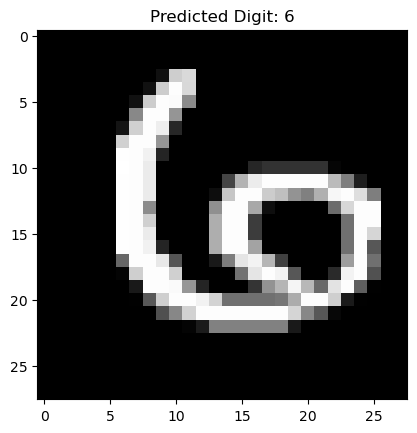

In [33]:
#TO DO - Plot Image
single_image_np = single_image.to_numpy().reshape(28,28)

# Display the image
plt.imshow(single_image_np, cmap='gray')
plt.title(f'Predicted Digit: {np.argmax(probabilities)}')
plt.show()


In [34]:
# TO DO - Print the value from y_test to compare with the image
actual_label = y_test.iloc[54]

print(f"Value from y_test: {actual_label}")


Value from y_test: 6
